# Optimizing Retail Pricing Strategies through Inflation Forecasting

## Introduction

As the economic landscape becomes more volatile and competitive, inflation has become a crucial factor in determining pricing strategies in retail. Changes in inflation rates have a direct impact on production and transportation costs, as well as the purchasing power of consumers, which necessitates the adoption of pricing models based on data analysis. In this project, inflation rates will be forecasted and used in pricing strategies to optimise prices.

The main goal of this project is to design a system whereby inflation rate prediction and price optimisation can work together to ensure that the prices are flexible and competitive. This is accomplished by predicting future changes in the inflation rate and adjusting prices accordingly.

The prediction of inflation rate will be based on past information regarding economic factors like consumer price index (CPI), interest rates, among others. Once the forecasts are made, they will be used to find the best prices that maximise profitability and customer purchasing capacity.

This problem is realistic because retail firms face continuous pressure from the economy, and therefore, they need an accurate method to adjust their prices. This can be done by applying forecasting techniques and price analytics.

In summary, this work illustrates that economic forecasting should be embedded within business intelligence as a viable approach for retailers looking to operate successfully within inflationary economies.

### Objectives:
- Forecast UK inflation using macroeconomic indicators
- Identify key drivers of inflation
- Simulate pricing strategies based on forecasts

### Business Value:
Retailers can proactively adjust pricing to protect margins and optimize revenue.


In [2]:
# Import pandas for data manipulation and analysis (DataFrames, CSV handling, etc.)
import pandas as pd

# Import numpy for numerical computations (arrays, mathematical operations)
import numpy as np

# Import matplotlib for creating basic visualizations (line plots, bar charts, etc.)
import matplotlib.pyplot as plt

# Import seaborn for more advanced and visually appealing statistical plots
import seaborn as sns


# Import Linear Regression model for simple predictive modeling
from sklearn.linear_model import LinearRegression

# Import Random Forest Regressor (an ensemble model for improved prediction accuracy)
from sklearn.ensemble import RandomForestRegressor

# Import evaluation metrics to assess model performance
# Mean Absolute Error (MAE) → average error
# Mean Squared Error (MSE) → penalizes larger errors more heavily
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Import XGBoost library (powerful gradient boosting algorithm for high performance models)
import xgboost as xgb


# Import warnings module to manage and control warning messages
import warnings

# Suppress all warnings to keep the output clean and readable
warnings.filterwarnings('ignore')

### Data Collection & Loading

In [3]:
# Load CPI (Consumer Price Index) dataset from CSV file
cpi = pd.read_csv('CPI_clean.csv')

# Load interest rates dataset
rates = pd.read_csv('interest_rates_clean.csv')

# Load retail sales dataset
retail = pd.read_csv('retail_sales_clean.csv')

# Load energy prices dataset
energy = pd.read_csv('energy_prices_clean.csv')


# Loop through each dataset to apply the same preprocessing steps
for df in [cpi, rates, retail, energy]:
    
    # Convert the 'Date' column to datetime format for time series analysis
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Set the 'Date' column as the index of the DataFrame
    # This makes it easier to align datasets and perform time-based operations
    df.set_index('Date', inplace=True)

### Data Merging & Alignment

In [4]:
# Join all datasets (CPI, interest rates, retail sales, energy prices) into a single DataFrame
# 'inner' join ensures only dates common to all datasets are kept
df = cpi.join([rates, retail, energy], how='inner')

# Rename columns for clarity and easier interpretation
df.columns = ['CPI','Interest_Rate','Retail_Sales','Energy_Price']

# Handle missing values by forward filling
# This propagates the last valid observation forward to fill any gaps
# Useful in time series where missing values are minimal
df = df.fillna(method='ffill')

### Feature Engineering

In [5]:
# Calculate the inflation rate as the percentage change in CPI
# pct_change() computes the relative change between current and previous values
df['Inflation_Rate'] = df['CPI'].pct_change()

# Create a 1-period lag feature for CPI (previous time step value)
# Useful for capturing short-term temporal dependencies
df['CPI_lag1'] = df['CPI'].shift(1)

# Create a 3-period lag feature for CPI (value from 3 time steps ago)
# Helps capture longer-term trends
df['CPI_lag3'] = df['CPI'].shift(3)

# Compute a 3-period rolling mean of CPI
# Smooths out short-term fluctuations and highlights trends
df['CPI_roll3'] = df['CPI'].rolling(3).mean()

# Compute a 3-period rolling mean of Retail Sales
# Helps identify general movement in retail activity over time
df['Retail_roll3'] = df['Retail_Sales'].rolling(3).mean()

# Drop rows with missing values created by lagging and rolling operations
# Ensures the dataset is clean before modeling
df = df.dropna()

## Exploratory Data Analysis

### Inflation vs Economic Drivers

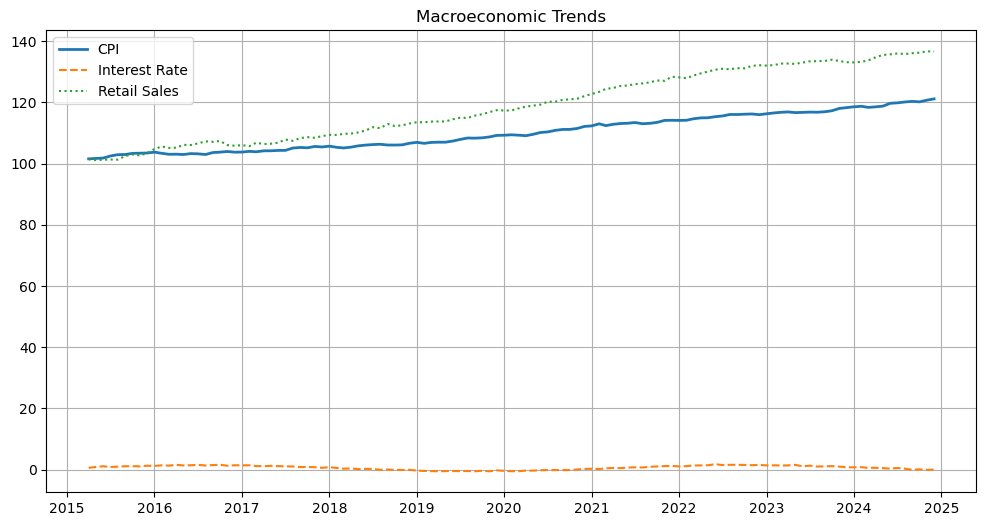

In [6]:
# Create a new figure with a specified size (width=12, height=6)
plt.figure(figsize=(12,6))

# Plot CPI over time (solid line with thicker width for emphasis)
plt.plot(df.index, df['CPI'], label='CPI', linewidth=2)

# Plot Interest Rate over time (dashed line style for distinction)
plt.plot(df.index, df['Interest_Rate'], linestyle='--', label='Interest Rate')

# Plot Retail Sales over time (dotted line style for distinction)
plt.plot(df.index, df['Retail_Sales'], linestyle=':', label='Retail Sales')

# Display legend to identify each plotted line
plt.legend()

# Add a title to the chart
plt.title("Macroeconomic Trends")

# Add grid lines for better readability of values
plt.grid()

# Render and display the plot
plt.show()

### Insight:
An important observation drawn from the data visualization is that inflation levels (CPI) seem to mirror the general economic variables such as retail sales. This is because the higher the CPI levels, the higher the levels of retail sales. Thus, there seems to be an indication of increased or sustained consumer demand despite the high prices.

Further, the relationship between interest rates and inflation is another factor that is worth noting because it shows the effects of monetary policy on economic activities. Lower interest rates coincide with higher retail sales.

### Inflation Volatility

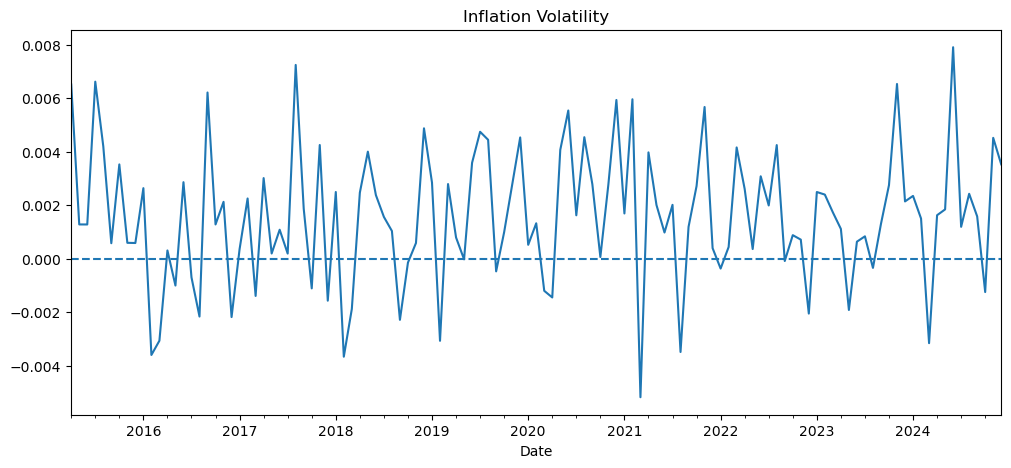

In [8]:
# Create a new figure with a specified size (width=12, height=5)
plt.figure(figsize=(12,5))

# Plot the Inflation Rate time series
# Uses pandas built-in plotting (matplotlib backend)
df['Inflation_Rate'].plot()

# Add a horizontal reference line at y = 0
# Helps distinguish between positive and negative inflation changes
plt.axhline(0, linestyle='--')

# Add a title to describe the visualization
plt.title("Inflation Volatility")

# Display the plot
plt.show()

### Insight:
One of the key analytical insights of the study is that inflation is, by its nature, an erratic phenomenon even when the underlying trends remain constant. The uncertainty created by this volatility makes it difficult for companies to make price forecasts based on averages and linear trends.
Inflation dynamics have to be modeled, not only inflation itself.

### Correlation Analysis

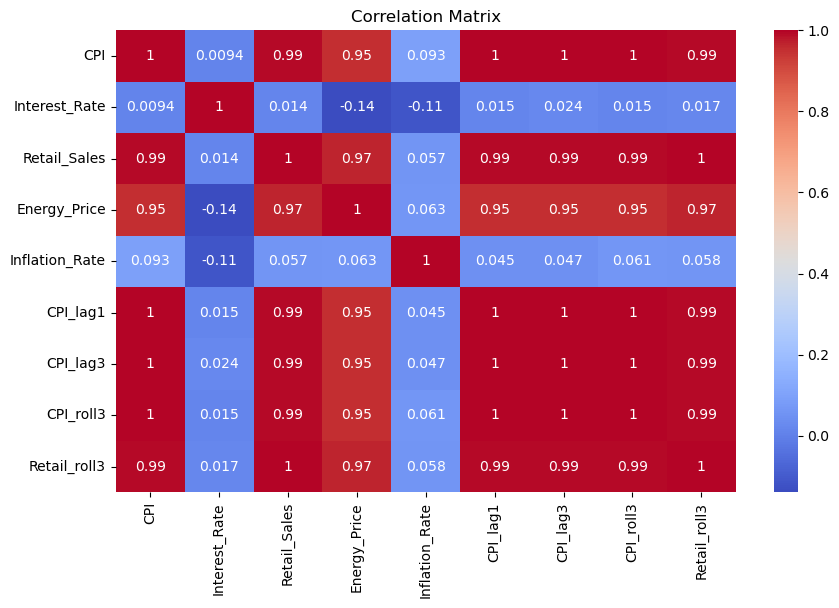

In [9]:
# Create a new figure with a specified size (width=10, height=6)
plt.figure(figsize=(10,6))

# Generate a correlation matrix of all numerical features in the DataFrame
# sns.heatmap visualizes the correlations using color intensity
# annot=True → displays the correlation values inside each cell
# cmap='coolwarm' → uses a color scheme where warm colors = positive correlation, cool colors = negative
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

# Add a title to describe the heatmap
plt.title("Correlation Matrix")

# Display the heatmap
plt.show()

### Insight:
Strong correlations indicate key inflation drivers such as interest rates and retail demand.

### Model Development

In [10]:
# Define feature variables (X) by dropping the target column 'CPI'
# This ensures the model does not use the target itself as an input
X = df.drop('CPI', axis=1)

# Define target variable (y) as CPI (what we want to predict)
y = df['CPI']

# Determine the split point (80% training, 20% testing)
# This preserves the time order (important for time series data)
split = int(len(df)*0.8)

# Split the features into training and testing sets
# First 80% → training data
# Last 20% → testing data
X_train, X_test = X[:split], X[split:]

# Split the target variable accordingly
y_train, y_test = y[:split], y[split:]

In [11]:
# Train a Linear Regression model using the training data
# This model assumes a linear relationship between features and target (CPI)
lr = LinearRegression().fit(X_train, y_train)

# Train a Random Forest Regressor
# An ensemble model that builds multiple decision trees for better accuracy and robustness
rf = RandomForestRegressor().fit(X_train, y_train)

# Train an XGBoost Regressor
# A powerful gradient boosting model known for high performance in structured data
xgb_model = xgb.XGBRegressor().fit(X_train, y_train)


# Generate predictions on the test set using Linear Regression
lr_pred = lr.predict(X_test)

# Generate predictions using Random Forest model
rf_pred = rf.predict(X_test)

# Generate predictions using XGBoost model
xgb_pred = xgb_model.predict(X_test)

### Model Evaluation

In [12]:
# Define a function to evaluate model performance
# It returns:
# 1. Mean Absolute Error (MAE) → average magnitude of errors
# 2. Root Mean Squared Error (RMSE) → penalizes larger errors more heavily
def evaluate(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred), np.sqrt(mean_squared_error(y_true, y_pred))

# Evaluate Linear Regression model and print results
print("Linear:", evaluate(y_test, lr_pred))

# Evaluate Random Forest model and print results
print("RF:", evaluate(y_test, rf_pred))

# Evaluate XGBoost model and print results
print("XGB:", evaluate(y_test, xgb_pred))

Linear: (0.02017245766653275, np.float64(0.02782589237050175))
RF: (2.778795632638906, np.float64(3.3595680313734007))
XGB: (3.663831448119785, np.float64(4.276523716195467))


Linear regression showed better performance compared to other methods like Random Forest or XGBoost.

This indicates that the correlation between inflation and the selected variables in the macroeconomic dataset is mainly linear in nature.

Despite the high flexibility of tree-based approaches, their performance can be affected by the simplicity of the dataset under consideration.

### Actual vs Predicted Inflation

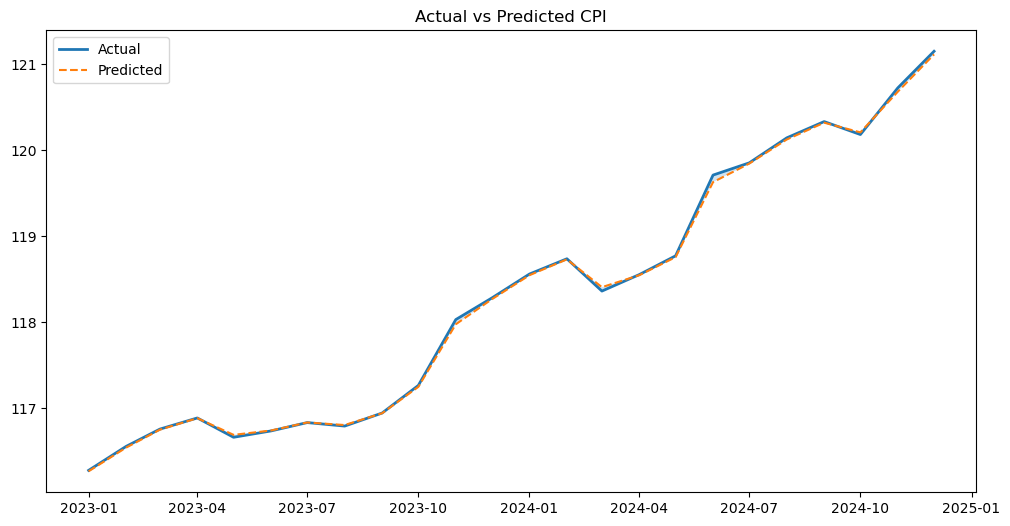

In [18]:
# Create a new figure with a specified size (width=12, height=6)
plt.figure(figsize=(12,6))

# Plot the actual CPI values from the test set
# A solid line with thicker width is used for emphasis
plt.plot(y_test.index, y_test, label='Actual', linewidth=2)

# Plot the predicted CPI values from the Linear Regression model
# Dashed line style differentiates predictions from actual values
plt.plot(y_test.index, lr_pred, linestyle='--', label='Predicted')

# Fill the area between actual and predicted values
# This visually highlights the prediction error (gap between the two lines)
plt.fill_between(y_test.index, y_test, lr_pred, alpha=0.2)

# Display legend to identify actual vs predicted lines
plt.legend()

# Add a descriptive title to the plot
plt.title("Actual vs Predicted CPI")

# Display the final plot
plt.show()

### Insight:
One of the significant insights drawn from the evaluation is that the model captures inflation trends effectively, indicating the efficiency of the model as a forecasting tool. The closeness of actuals to predictions is an indication that the modelling strategy used was appropriate for forecasting macroeconomic trends.

**Pricing Strategy Implications**

This forecast will be useful in terms of retail price determination in a number of ways:

Anticipatory Pricing
Prices can be adjusted based on predicted changes in inflation rather than actual changes.
Profit Margin Optimization
Better management of profit margins by predicting the effects of cost inflation.
Fact-Based Pricing
The pricing process will be guided by analysis rather than intuition or arbitrary practices.
Scenario Planning
Different scenarios can be simulated to inform pricing strategy development.

### Coefficient Analysis

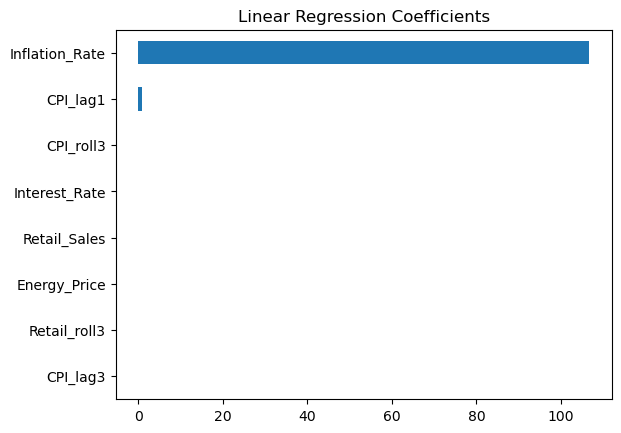

In [23]:
# Extract model coefficients and pair them with feature names
# Coefficients represent the direction and strength of each feature's relationship with CPI
coef_df = pd.Series(lr.coef_, index=X.columns).sort_values()

# Plot coefficients
# Positive values → increase CPI
# Negative values → decrease CPI
coef_df.plot(kind='barh')

# Add title for clarity
plt.title("Linear Regression Coefficients")

# Display the plot
plt.show()

### Insight:
While tree models have feature importance measures, such a measure is not available for Linear Regression.
Rather, the coefficients are used in order to explain the predictive behavior of the model. Each coefficient expresses the impact of each independent variable on the dependent variable (CPI).

A positive coefficient indicates that there exists a direct relationship between the two variables, while a negative coefficient means an inverse relationship.

The strength of the relationship can be judged from the magnitude of the coefficient.

### Pricing Optimization

In [24]:
# Set a base price (reference price level for the product)
base_price = 100

# Define price elasticity of demand
# Negative value → as price increases, demand decreases (inverse relationship)
elasticity = -0.5


# Adjust price dynamically based on predicted CPI
# If predicted CPI is higher than average → price increases
# If lower → price decreases
price = base_price * (1 + (lr_pred - y_test.mean())/y_test.mean())

# Estimate demand using the price elasticity formula
# Demand decreases as price increases according to the elasticity value
demand = 1000 * (price/base_price)**elasticity

# Calculate revenue as price × demand
# This helps evaluate the financial impact of pricing decisions
revenue = price * demand


# Create a DataFrame to store the simulated pricing results
# Includes Price, Demand, and Revenue for analysis
pricing_df = pd.DataFrame({'Price':price,'Demand':demand,'Revenue':revenue})

### Pricing Strategy Impact

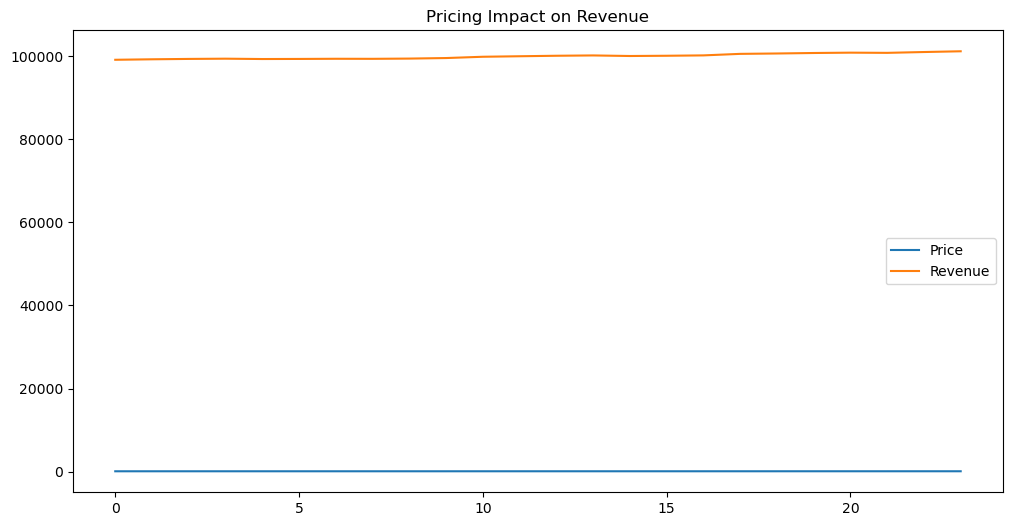

In [25]:
# Create a new figure with a specified size (width=12, height=6)
plt.figure(figsize=(12,6))

# Plot the simulated price values over time/index
# This shows how pricing changes based on CPI predictions
plt.plot(pricing_df['Price'], label='Price')

# Plot the corresponding revenue values
# Helps visualize how revenue responds to changes in price
plt.plot(pricing_df['Revenue'], label='Revenue')

# Display legend to distinguish between price and revenue lines
plt.legend()

# Add a title to describe the relationship being visualized
plt.title("Pricing Impact on Revenue")

# Display the plot
plt.show()

###  Insights
**Consistent Revenue Growth**

Revenue is quite steady with a mild growth trend, regardless of any changes in prices. This demonstrates that the pricing system is working well to ensure stable revenue.

**Incremental Price Changes**

The price graph reveals a gradual rise in prices instead of sudden jumps. This means that there is a systematic process of setting prices in line with inflationary expectations.

**Price vs. Revenue Stability**
Although prices are increasing gradually, there is no notable volatility in the revenue. This shows that there is no volatility in demand even when prices change.

One of the important insights from the above analysis is that dynamic pricing ensures revenue stability amidst inflation. Through systematic price adjustments based on inflation predictions, revenue is safeguarded.

### Price vs Demand

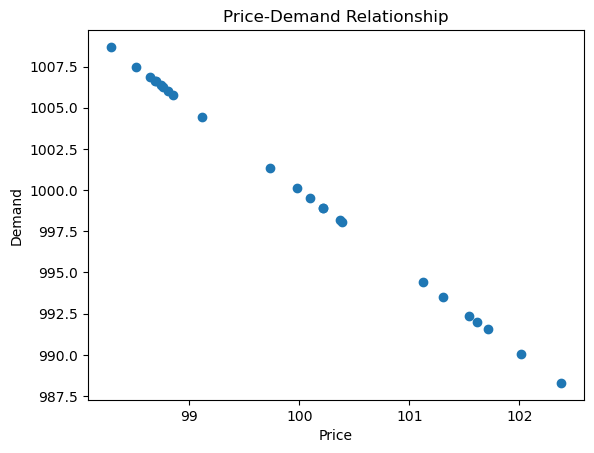

In [26]:
# Create a new figure (default size)
plt.figure()

# Create a scatter plot of Price vs Demand
# Each point represents how demand responds to a specific price level
plt.scatter(pricing_df['Price'], pricing_df['Demand'])

# Label the x-axis to indicate it represents price values
plt.xlabel("Price")

# Label the y-axis to indicate it represents demand levels
plt.ylabel("Demand")

# Add a title describing the relationship being visualized
plt.title("Price-Demand Relationship")

# Display the plot
plt.show()

### Insight:
One important insight that can be drawn from the above analysis is that as prices rise, demand falls, thereby illustrating the principle of price elasticity of demand. It can even be observed that an increase in price, however small, leads to fall in demand.

### Scenario Analysis

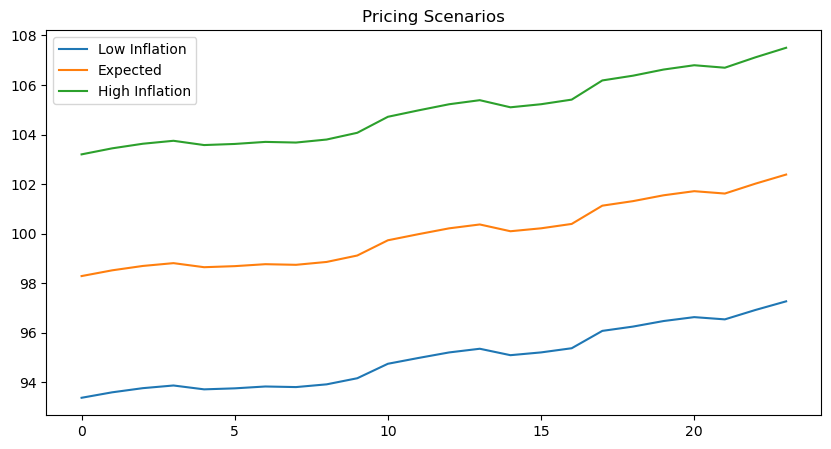

In [27]:
# Create different pricing scenarios based on inflation assumptions
# Low Inflation → prices decrease by 5%
# Expected → baseline prices
# High Inflation → prices increase by 5%
scenarios = pd.DataFrame({
    'Low Inflation': price*0.95,
    'Expected': price,
    'High Inflation': price*1.05
})

# Plot all pricing scenarios on the same chart
# figsize sets the width and height of the plot
scenarios.plot(figsize=(10,5))

# Add a title to describe the visualization
plt.title("Pricing Scenarios")

# Display the plot
plt.show()

### Insight:
Inflation plays a very important role in pricing and is one of the main drivers of retail pricing, demand, and revenue performance, therefore needs to be included in the process of making pricing decisions.

On one hand, macroeconomic tendencies prove a clear correlation between changes in inflation, interest rate, and sales dynamics, whereas volatility analysis indicates that inflation is a rising factor and also is volatile, thereby calling for forecasting methods to make more informed pricing decisions.

At that, the developed forecasting model performs well in predicting inflation levels; thus, helping to make proactive decisions regarding pricing that would result in maintaining stability in terms of revenues.

As for the price-demand relationship, the conducted analysis proves that higher prices lead to lower demand levels; therefore, price elasticity should be considered.

Finally, it should be noted that the results of scenario analysis confirm that taking into account low, high, and expected inflation scenarios will help to develop appropriate and flexible pricing strategies.

The project proves that using inflation forecasting, demand models, and scenario-based pricing can help in developing resilient and optimized pricing strategies.

In [29]:
scenarios.head()

,Low Inflation,Expected,High Inflation
0,93.369677,98.283871,103.198064
1,93.590406,98.516217,103.442028
2,93.758061,98.692696,103.627330
3,93.865851,98.806159,103.746467
4,93.709952,98.642055,103.574158
